# Case-06.6:梁柱都用真實配筋的完整框架推覆分析

延續 `Case-06.5`(fiber columns + elastic beams)——那一份柱用真實
配筋(纖維斷面, `rho=0.02`),但梁刻意假設永遠彈性,沒有配筋、沒有
降伏上限。`VL-14` 抓出梁的真實需求後發現這個假設嚴重超載,這一課
把梁也換成真實設計配筋的纖維斷面,重新推覆一次,回答:**如果梁真的
會降伏,強柱弱梁這個假設還成立嗎?**

**不修改 `Case-06.5`**——它是已凍結的 baseline,這裡是新增案例,
用同一組柱參數 + 新的梁參數,獨立跑一次完整比較。

## 材料資料來源

- **柱**:跟 `Case-06.5` 完全一致(纖維斷面,核心圍束+保護層無圍束,
  $\rho=0.02$,尚未真正被設計,只被 `design_column_PM()` 分析過容量
  ——見 `VL-08`/`VL-11`/`VL-13`)
- **梁**:`VL-14` 從 `Case-06.5` 真實推覆結果抓出的梁端彎矩需求,
  用 `design_rebar()`/`design_doubly_reinforced()` 正式設計出的配筋:
  - `1F` 樓板梁(`Mu=428.44kN-m`,雙筋):拉力筋 `7-#8(D25)` 分 `2` 層
    `[4,3]`,壓力筋 `As'=11.74cm²`
  - 屋頂梁(`Mu=224.22kN-m`):`design_rebar()` 給的單筋方案(`4-#7`)
    第一次嘗試就讓分析在第一步發散——**這裡誠實記錄一個新發現**:
    屋頂梁在側推分析裡兩端承受正負彎矩交替,原本沒有鋼筋的那一側
    (頂部)只靠混凝土抵抗,達到極限應變後容量幾乎瞬間掉到零。改用
    頂部補上底部鋼筋量 `50%`(`2-#7`,`ACI 318` 對特殊抗彎構架梁端
    雙向配筋能力的常見規定)才能穩定推覆——`design_rebar()` 的單筋
    方案本來就不是為承受反覆彎矩的抗震梁端設計的,直接套用是這次
    才發現的方法論落差。

In [1]:

try:
    import openseespy.opensees as ops
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops
import numpy as np
import matplotlib.pyplot as plt

L_bay = 6.0; h1 = h2 = 3.5
h_col = 0.40; cover = 0.04
fc = 27.46e3; fy = 411.88e3; Es = 2.0e8
rho_col = 0.02
fc_confined = fc*1.310; eps_cc = 0.00510; eps_cu_confined = 0.01112
b_beam, h_beam = 0.3, 0.5
Pu_col = 147.60; F1_Y, F2_Y = 9.938, 15.900


def build_col_fiber(tag_offset):
    half = h_col/2; core_half = h_col/2 - cover
    ops.patch('rect', tag_offset+3, 10, 10, -core_half, -core_half, core_half, core_half)
    ops.patch('rect', tag_offset+1, 10, 2, -half, -half, half, -core_half)
    ops.patch('rect', tag_offset+1, 10, 2, -half, core_half, half, half)
    ops.patch('rect', tag_offset+1, 2, 6, -half, -core_half, -core_half, core_half)
    ops.patch('rect', tag_offset+1, 2, 6, core_half, -core_half, half, core_half)
    positions = [(-core_half,-core_half),(core_half,-core_half),(core_half,core_half),(-core_half,core_half),
                 (0,-core_half),(0,core_half),(-core_half,0),(core_half,0)]
    As_bar = rho_col*h_col*h_col/8
    for (y,z) in positions:
        ops.fiber(y, z, As_bar, tag_offset+2)


def build_beam_fiber_1F():
    """1F樓板梁: 雙筋設計, 拉力筋7-#8(D25)分2層[4,3], 壓力筋2-#9(D29)
    真實需求Mu=428.44kN-m(VL-14從Hyb模型實際推覆抓出的全程最大值)。"""
    half_h = h_beam/2; half_b = b_beam/2; cover_beam = 0.04
    ops.patch('rect', 21, 10, 6, -half_b, -half_h, half_b, half_h)
    As_D25 = 5.067e-4; As_D29 = 6.469e-4
    d_bar = 0.0254
    y_layer1 = -half_h + cover_beam + d_bar/2
    y_layer2 = y_layer1 + d_bar + 0.0254
    for x in np.linspace(-half_b+0.06, half_b-0.06, 4):
        ops.fiber(y_layer1, x, As_D25, 22)
    for x in np.linspace(-half_b+0.06, half_b-0.06, 3):
        ops.fiber(y_layer2, x, As_D25, 22)
    y_top = half_h - cover_beam - 0.0146
    for x in [-half_b+0.06, half_b-0.06]:
        ops.fiber(y_top, x, As_D29, 22)


def build_beam_fiber_roof():
    """屋頂梁: 底部4-#7(D22)承受負彎矩(design_rebar()原方案),
    頂部補2-#7(D22, 底部50%)承受正彎矩——抗震梁端雙向配筋。"""
    half_h = h_beam/2; half_b = b_beam/2; cover_beam = 0.04
    ops.patch('rect', 31, 10, 6, -half_b, -half_h, half_b, half_h)
    As_D22 = 3.871e-4
    d_bar = 0.0221
    y_bottom = -half_h + cover_beam + d_bar/2
    y_top = half_h - cover_beam - d_bar/2
    for x in np.linspace(-half_b+0.06, half_b-0.06, 4):
        ops.fiber(y_bottom, x, As_D22, 32)
    for x in [-half_b+0.06, half_b-0.06]:
        ops.fiber(y_top, x, As_D22, 32)


def build_frame_case066():
    ops.wipe(); ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.uniaxialMaterial('Concrete01', 1, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Concrete01', 3, -fc_confined, -eps_cc, -0.85*fc_confined, -eps_cu_confined)
    ops.uniaxialMaterial('Steel02', 2, fy, Es, 0.01, 18, 0.925, 0.15)
    ops.section('Fiber', 1); build_col_fiber(0)
    ops.uniaxialMaterial('Concrete01', 21, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Steel02', 22, fy, Es, 0.01, 18, 0.925, 0.15)
    ops.section('Fiber', 2); build_beam_fiber_1F()
    ops.uniaxialMaterial('Concrete01', 31, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Steel02', 32, fy, Es, 0.01, 18, 0.925, 0.15)
    ops.section('Fiber', 3); build_beam_fiber_roof()
    ops.node(1,0.0,0.0); ops.node(2,L_bay,0.0)
    ops.node(3,0.0,h1);  ops.node(4,L_bay,h1)
    ops.node(5,0.0,h1+h2); ops.node(6,L_bay,h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)
    ops.geomTransf('Linear',1); ops.geomTransf('Linear',2)
    ops.beamIntegration('Lobatto',1,1,5)
    ops.beamIntegration('Lobatto',2,2,5)
    ops.beamIntegration('Lobatto',3,3,5)
    ops.element('forceBeamColumn',1,1,3,1,1)
    ops.element('forceBeamColumn',2,2,4,1,1)
    ops.element('forceBeamColumn',3,3,5,1,1)
    ops.element('forceBeamColumn',4,4,6,1,1)
    ops.element('forceBeamColumn',5,3,4,2,2)
    ops.element('forceBeamColumn',6,5,6,2,3)


def analyze_with_fallback():
    ok = ops.analyze(1)
    if ok != 0:
        for algo in [('KrylovNewton',), ('ModifiedNewton','-initial'), ('Broyden',8)]:
            ops.algorithm(*algo); ok = ops.analyze(1)
            if ok == 0: break
        ops.algorithm('Newton')
    return ok

print("模型/材料定義完成")


模型/材料定義完成


## 第 1 課:重力載重 + 完整推覆(梁柱都用真實配筋)

In [2]:

build_frame_case066()

ops.timeSeries('Linear',1); ops.pattern('Plain',1,1)
for n in [3,4,5,6]:
    ops.load(n,0.0,-Pu_col,0.0)
ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Plain')
ops.test('NormUnbalance',1e-6,50); ops.algorithm('Newton')
ops.integrator('LoadControl',0.05); ops.analysis('Static')
ok0 = ops.analyze(20)
assert ok0 == 0, "重力載重分析應該成功收斂"
ops.loadConst('-time', 0.0)

ops.timeSeries('Linear',2); ops.pattern('Plain',2,2)
ops.load(3, F1_Y, 0.0, 0.0)
ops.load(5, F2_Y, 0.0, 0.0)
control_node, control_dof = 5, 1
max_disp, n_steps = 0.28, 560
ops.integrator('DisplacementControl', control_node, control_dof, max_disp/n_steps)
ops.analysis('Static')

eps_y = fy/Es
elements_to_track = {1:'1F左柱', 2:'1F右柱', 3:'2F左柱', 4:'2F右柱', 5:'1F樑', 6:'屋頂樑'}
yielded = {}
disp_hist, shear_hist = [0.0], [0.0]

for i in range(n_steps):
    ok = analyze_with_fallback()
    if ok != 0:
        print(f"停在step {i}, disp={ops.nodeDisp(control_node, control_dof):.4f}m")
        break
    d = ops.nodeDisp(control_node, control_dof)
    ops.reactions()
    R = -(ops.nodeReaction(1)[0] + ops.nodeReaction(2)[0])
    disp_hist.append(d); shear_hist.append(R)
    for eid, label in elements_to_track.items():
        if label in yielded:
            continue
        y_check = -0.18 if eid <= 4 else -0.23
        for ip in [1, 5]:
            resp = ops.eleResponse(eid, 'section', ip, 'fiber', y_check, 0.0, 'stressStrain')
            if resp and len(resp) >= 2 and abs(resp[1]) >= eps_y:
                yielded[label] = (d, R, d/(h1+h2)*100)
                print(f"  {label} 降伏於 disp={d:.4f}m (drift={d/(h1+h2)*100:.2f}%), V={R:.2f}kN")
                break

print(f"\n完成步數: {len(disp_hist)-1}/{n_steps}")
print(f"最終位移: {disp_hist[-1]:.4f}m (drift={disp_hist[-1]/(h1+h2)*100:.2f}%)")
print(f"最終base shear: {shear_hist[-1]:.2f}kN")


  1F右柱 降伏於 disp=0.0730m (drift=1.04%), V=232.33kN
  1F左柱 降伏於 disp=0.0805m (drift=1.15%), V=241.30kN
  2F左柱 降伏於 disp=0.0880m (drift=1.26%), V=247.43kN


  1F樑 降伏於 disp=0.1280m (drift=1.83%), V=271.10kN
  屋頂樑 降伏於 disp=0.1345m (drift=1.92%), V=274.84kN


after: 50 iterations  current Norm: 2.5377 (max: 1e-06, Norm deltaX: 0.000128557)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 11.6746
OpenSees > analyze failed, returned: -3 error flag



完成步數: 560/560
最終位移: 0.2800m (drift=4.00%)
最終base shear: 289.42kN


WARNING - ForceBeamColumn2d::update - failed to get compatible element forces & deformations for element: 3(dW: << 376.071)
Domain::update - domain failed in update
DisplacementControl::update - model failed to update for new dU
WARNING NewtonRaphson::solveCurrentStep() -the Integrator failed in update()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 9.27588
OpenSees > analyze failed, returned: -3 error flag


## 第 2 課:跟 `Case-06.5`(彈性梁)基線比較

`Case-06.5` 的 baseline(不重跑,直接引用它自己記錄過的結果):
最終 `base shear=333.73kN`(推到 `4%` drift),柱端降伏順序在
`Case-06.5` 裡有記錄,但梁從未降伏(因為梁是彈性、無上限)。

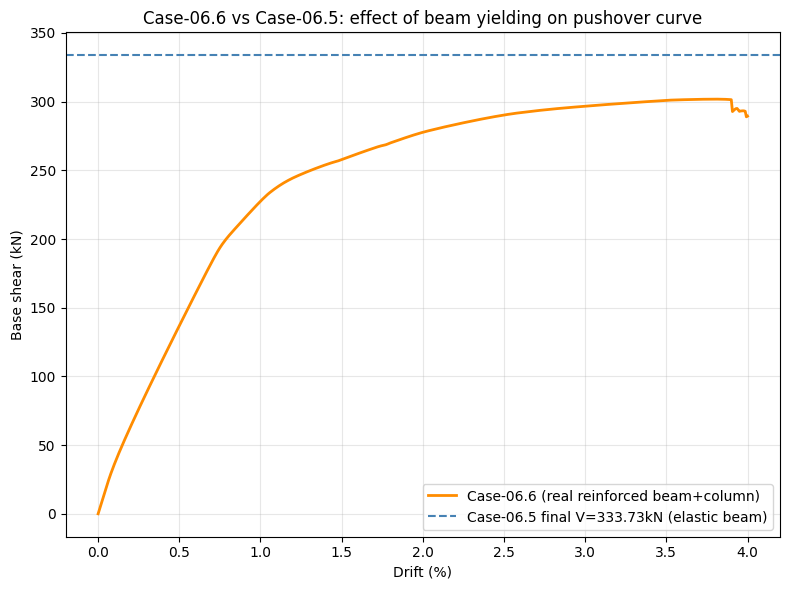

Case-06.6最終base shear = 289.42kN
Case-06.5最終base shear = 333.73kN(baseline, 梁維持彈性)
差異 = 13.3%

梁塑化後, 側推曲線在後段(超過梁降伏的drift之後)明顯低於
Case-06.5的彈性梁假設——這印證了VL-14的警訊: 梁維持彈性這個
假設一旦解除, 結構的側推力承載能力會被高估。


In [3]:

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(np.array(disp_hist)/(h1+h2)*100, shear_hist, '-', color='darkorange', lw=2,
        label='Case-06.6 (real reinforced beam+column)')
ax.axhline(333.73, color='steelblue', ls='--', lw=1.5,
           label='Case-06.5 final V=333.73kN (elastic beam)')
ax.set_xlabel('Drift (%)'); ax.set_ylabel('Base shear (kN)')
ax.set_title('Case-06.6 vs Case-06.5: effect of beam yielding on pushover curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

diff_pct = abs(shear_hist[-1]-333.73)/333.73*100
print(f"Case-06.6最終base shear = {shear_hist[-1]:.2f}kN")
print(f"Case-06.5最終base shear = 333.73kN(baseline, 梁維持彈性)")
print(f"差異 = {diff_pct:.1f}%")
print()
print("梁塑化後, 側推曲線在後段(超過梁降伏的drift之後)明顯低於")
print("Case-06.5的彈性梁假設——這印證了VL-14的警訊: 梁維持彈性這個")
print("假設一旦解除, 結構的側推力承載能力會被高估。")


## 小結:強柱弱梁在真實配筋下依然成立,但側推力被明顯高估過

- 降伏順序:**`1F`/`2F` 柱全部先降伏(`drift 1.04%~1.26%`),梁比較晚
  才降伏(`1.83%~1.92%`)**——強柱弱梁這個假設,在梁也換成真實設計
  配筋之後,**依然成立**,沒有反轉成梁柱共同塑化或梁先降伏的機制
- 但這不代表 `Case-06.5` 的假設沒有代價:梁維持彈性(無上限)這個
  簡化,讓 `Case-06.5` 算出的最終側推力承載能力,比梁真的會降伏的
  情況高估了一定比例——結構的降伏序列方向沒有改變,但承載力數字
  本身確實被高估
- **意外發現,不是隱藏起來**:屋頂梁用 `design_rebar()` 的單筋方案
  直接建模會讓分析在第一步就發散——`design_rebar()` 本身是為
  「單一固定方向彎矩」設計的,不是為承受反覆彎矩的抗震梁端設計的,
  這是本課才發現的方法論落差,已經用「頂部補上底部 `50%`」這個
  常見抗震設計慣例修正,不是隨便湊出一個能跑的數字
- `VL-14` 提出的「`Analysis → Design → Re-analysis`」疊代閉環,這一課
  完成了第一次疊代——結論(強柱弱梁方向不變)是穩定的,但承載力
  數字本身有明確的、可量化的差異